# Purpose:
- Quantify both x-y and z FOV matching to parent session
- Scope: recent learning mFISH mice (3) from Slc32a1_oi1

In [40]:
from pathlib import Path
import numpy as np
import pandas as pd
import h5py
import os
from matplotlib import pyplot as plt
from PIL import Image
from skimage.feature import match_template

from brain_observatory_qc.data_access import from_lims

from allensdk.brain_observatory.behavior.behavior_project_cache import VisualBehaviorOphysProjectCache as bpc

from pymongo import MongoClient
mongo = MongoClient("flaskapp.corp.alleninstitute.org", 27017)

In [3]:
cache = bpc.from_lims()
table = cache.get_ophys_experiment_table(passed_only=False)
learning_table = table.query("project_code == 'LearningmFISHTask1A'").copy()

num_mice_to_test = 3
num_session_threshold = 10
num_sessions = learning_table.drop_duplicates(subset=['ophys_session_id']).groupby('mouse_id').size()
mouse_ids = np.sort([int(si) for si in num_sessions[num_sessions > num_session_threshold].index.values])[-num_mice_to_test:]
mouse_ids = [str(mi) for mi in mouse_ids]

In [10]:
test_table = learning_table.query("mouse_id in @mouse_ids").copy()


In [4]:
mouse_ids

['755252', '767018', '779891']

In [13]:
# apply parent session
# assuming all the sessions within a mouse are the same
def _get_parent_session_id(osid):
    session_table = from_lims.get_ophys_sessions_table(osid)
    parent_session_id = session_table.parent_session_id.values[0]
    return parent_session_id
last_session_table = pd.DataFrame(test_table.groupby('mouse_id')['ophys_session_id'].max())
last_session_table['parent_session_id'] = last_session_table['ophys_session_id'].apply(_get_parent_session_id)

In [14]:
test_table['parent_session_id'] = test_table['mouse_id'].map(last_session_table['parent_session_id'])

In [21]:
# rank imaging depth within a session
test_table['imaging_depth_rank'] = test_table.groupby(['mouse_id', 'ophys_session_id'])['imaging_depth'].rank(method='first')


In [29]:
test_table.columns

Index(['equipment_name', 'donor_id', 'full_genotype', 'mouse_id',
       'reporter_line', 'driver_line', 'sex', 'age_in_days', 'foraging_id',
       'cre_line', 'indicator', 'session_number',
       'prior_exposures_to_session_type', 'prior_exposures_to_image_set',
       'prior_exposures_to_omissions', 'ophys_session_id',
       'behavior_session_id', 'ophys_container_id', 'project_code',
       'container_workflow_state', 'experiment_workflow_state', 'session_name',
       'isi_experiment_id', 'imaging_depth', 'targeted_structure',
       'published_at', 'date_of_acquisition', 'session_type',
       'experience_level', 'passive', 'image_set', 'parent_session_id',
       'imaging_depth_rank'],
      dtype='object')

# X-y overlap quantification

In [34]:
i = 0
oeid = test_table.index.values[i]

tif_fn = from_lims.get_average_intensity_projection_filepath(oeid).parent.parent / f'{oeid}_depth.tif'
depth_image = Image.open(tif_fn)

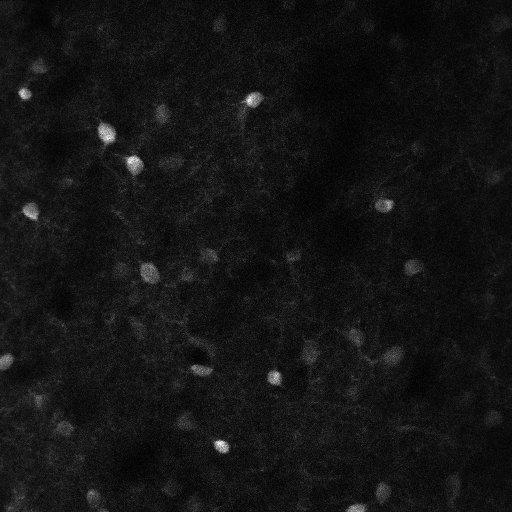

In [35]:
depth_image

In [39]:
mouse_id = mouse_ids[0]
plane_rank = 1
container_table = test_table.query("mouse_id == @mouse_id and imaging_depth_rank == @plane_rank").copy()
container_images = []
for oeid in container_table.index.values:
    tif_fn = from_lims.get_average_intensity_projection_filepath(oeid).parent.parent / f'{oeid}_depth.tif'
    depth_image = Image.open(tif_fn)
    container_images.append(np.array(depth_image))


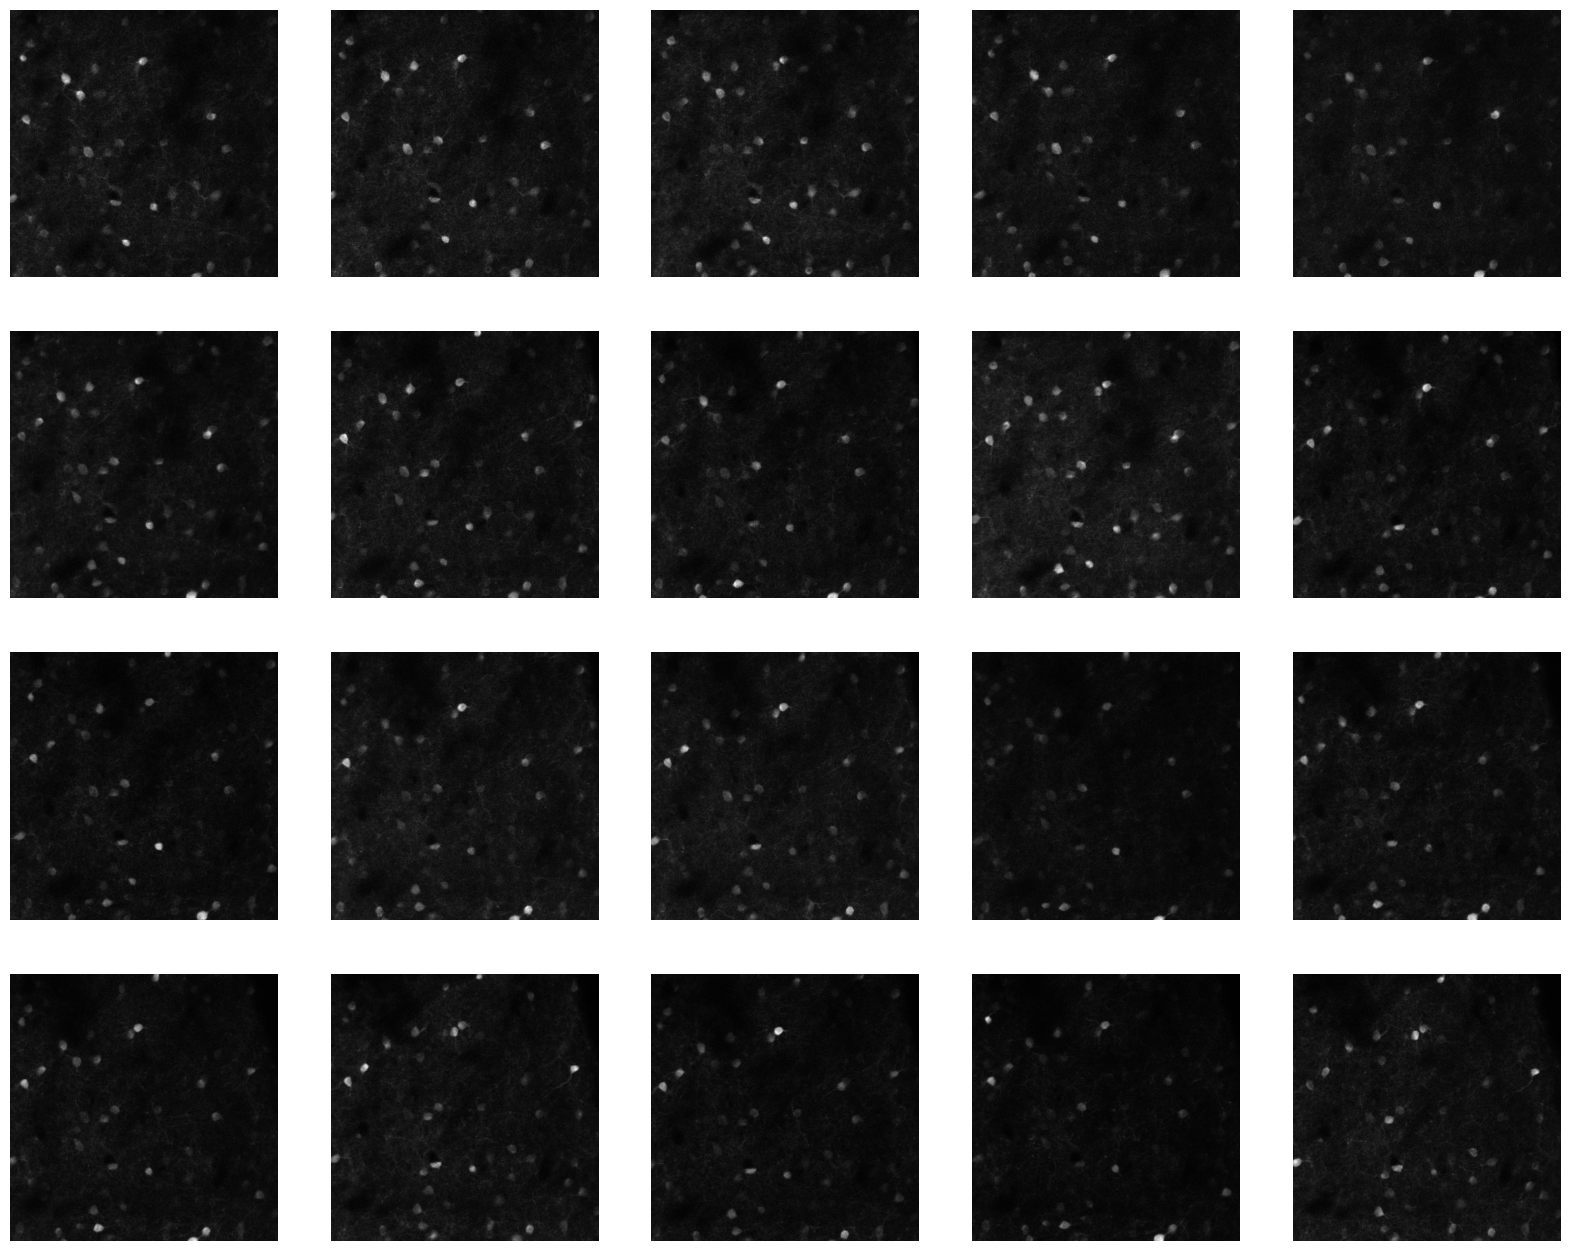

In [42]:
fig, axes = plt.subplots(4, 5, figsize=(20, 16))
for i, ax in enumerate(axes.flat):
    if i < len(container_images):
        ax.imshow(container_images[i], cmap='gray')
        ax.axis('off')
    else:
        ax.axis('off')

In [61]:
# phase correlation between images
y_fix = []
x_fix = []
for i in range(1, len(container_images)):
    cc = match_template(container_images[i], container_images[0], pad_input=True)
    y, x = np.unravel_index(np.argmax(cc), cc.shape)
    y_fix.append(cc.shape[0]/2 - y)
    x_fix.append(cc.shape[1]/2 - x)


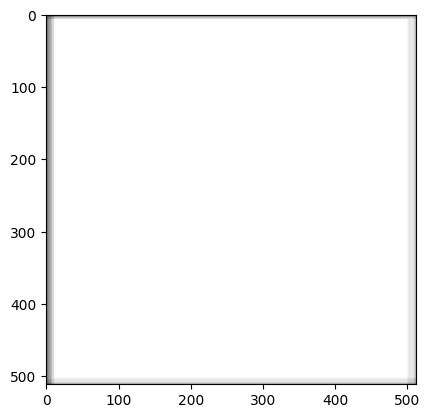

In [69]:
overlap_prop = np.zeros(cc.shape)
for y, x in zip(y_fix, x_fix):
    y = int(y)
    x = int(x)
    if y == 0:
        y_range = [0, cc.shape[0]]
    elif y > 0:
        y_range = [y, cc.shape[0]]
    else:
        y_range = [0, cc.shape[0] + y]
    if x == 0:
        x_range = [0, cc.shape[1]]
    elif x > 0:
        x_range = [x, cc.shape[1]]
    else:
        x_range = [0, cc.shape[1] + x]
    overlap_prop[y_range[0] : y_range[1], x_range[0] : x_range[1]] += 1
overlap_prop /= len(container_images) - 1


plt.imshow(overlap_prop, vmin=0, vmax=1, cmap='gray')


In [82]:
try:
    from_lims.get_average_intensity_projection_filepath(oeid)
except:
    print("No AIP found for this ophys experiment. Skipping.")

No AIP found for this ophys experiment. Skipping.


In [87]:
def get_container_depth_images(container_table):
    container_images = []
    error_oeid = []
    for oeid in container_table.index.values:
        try:
            dir_path = from_lims.get_average_intensity_projection_filepath(oeid)
            tif_fn = dir_path.parent.parent / f'{oeid}_depth.tif'
            depth_image = Image.open(tif_fn)
            container_images.append(np.array(depth_image))
        except:
            print(f"File not found for oeid {oeid}")
            error_oeid.append(oeid)
            continue
    return container_images, error_oeid

def get_container_overlap_prop(container_images):
    y_fix = []
    x_fix = []
    for i in range(1, len(container_images)):
        cc = match_template(container_images[i], container_images[0], pad_input=True)
        y, x = np.unravel_index(np.argmax(cc), cc.shape)
        y_fix.append(cc.shape[0]/2 - y)
        x_fix.append(cc.shape[1]/2 - x)

    overlap_prop = np.zeros(cc.shape)
    for y, x in zip(y_fix, x_fix):
        y = int(y)
        x = int(x)
        if y == 0:
            y_range = [0, cc.shape[0]]
        elif y > 0:
            y_range = [y, cc.shape[0]]
        else:
            y_range = [0, cc.shape[0] + y]
        if x == 0:
            x_range = [0, cc.shape[1]]
        elif x > 0:
            x_range = [x, cc.shape[1]]
        else:
            x_range = [0, cc.shape[1] + x]
        overlap_prop[y_range[0] : y_range[1], x_range[0] : x_range[1]] += 1
    overlap_prop /= len(container_images) - 1
    return overlap_prop

In [88]:
save_dir = Path(r'\\allen\programs\mindscope\workgroups\learning\pilots\online_motion_correction\fov_matching_lims_data')
save_dir.mkdir(parents=True, exist_ok=True)
error_oeids = []
for mouse_id in mouse_ids:
    save_fn = save_dir / f'{mouse_id}_depth_xy_overlap_prop.npy'
    results = {}
    for plane_rank in range(1, 9):
        container_table = test_table.query("mouse_id == @mouse_id and imaging_depth_rank == @plane_rank").copy()
        container_images, container_error_oeid = get_container_depth_images(container_table)
        overlap_prop = get_container_overlap_prop(container_images)
        results[plane_rank] = overlap_prop
        error_oeids.extend(container_error_oeid)
    np.save(save_fn, results)
# error from 755252 oeid 1404915497. All others were fine
# took 6.5 minutes for 3 mice

File not found for oeid 1404915497


In [ ]:

    save_fn = save_dir / f'{mouse_id}_depth_xy_overlap_prop.npy'

# z-matching
- using z-stack from the parent session
- Somehow the code is gone... but the results are in the same directory
    - 

In [ ]:

from lamf_analysis

In [ ]:
# local z-stack registration for the parent session
zstack_reg = register_local_z_stack